BERT Sentiment Analysis Project

 CELL 1: Install Required Libraries

In [1]:
!pip install transformers
!pip install torch
!pip install datasets
!pip install scikit-learn
!pip install pandas numpy matplotlib seaborn

CELL 2: Import Libraries

In [2]:
from torch.optim import AdamW


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW 
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


 Check if we have GPU available

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


CELL 3: Load Dataset

Load your dataset here - replace with actual path
For this example, we're using a CSV file with 'text' and 'sentiment' columns sentiment: 0 = negative, 1 = neutral, 2 = positive


In [5]:
import os
os.getcwd()

'C:\\Users\\shiva'

In [6]:
os.chdir('C:\\Users\\shiva\\Desktop\\datasets')

In [7]:
df=pd.read_csv('Twitter_Data.csv')

In [8]:
print(df.columns)
df['category'].value_counts()

Index(['clean_text', 'category'], dtype='object')


category
 1    4153
 0    3477
-1    2369
Name: count, dtype: int64

In [9]:
print(df.columns.tolist())

['clean_text', 'category']


In [10]:
print(f"Dataset loaded! Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nSentiment distribution:")
print(df['category'].value_counts())

Dataset loaded! Shape: (9999, 2)

First few rows:
                                          clean_text  category
0  when modi promised “minimum government maximum...        -1
1  talk all the nonsense and continue all the dra...         0
2  what did just say vote for modi  welcome bjp t...         1
3  asking his supporters prefix chowkidar their n...         1
4  answer who among these the most powerful world...         1

Sentiment distribution:
category
 1    4153
 0    3477
-1    2369
Name: count, dtype: int64


CELL 4: Clean the Data
Let's clean up the text data

In [68]:
# Clean text function
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    return text

# Clean text
df['clean_text'] = df['clean_text'].apply(clean_text)

# Remove empty texts
df = df[df['clean_text'] != '']

# Remove invalid labels (if any)
df = df[df['category'] != -1].reset_index(drop=True)

# Prepare texts and labels
texts = df['clean_text'].values
labels = df['category'].values

print(f"After cleaning, dataset shape: {df.shape}")
print(f"Unique labels: {df['sentiment'].unique()}")



After cleaning, dataset shape: (7629, 3)
Unique labels: [1 2]


In [69]:
df = df[df['sentiment'] != -1].reset_index(drop=True)


 CELL 5: Split the Data


In [71]:
# Prepare texts and labels
texts = df['clean_text'].values
labels = df['category'].values

# Train/validation/test split
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Test samples: {len(test_texts)}")
print(f"Unique training labels: {np.unique(train_labels)}")


Training samples: 5340
Validation samples: 1144
Test samples: 1145
Unique training labels: [0 1]


In [72]:
# Determine number of unique classes
num_classes = len(np.unique(df['sentiment']))  # Should be 3

# Load pre-trained BERT for classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes,   # <-- Must match your labels
    output_attentions=False,
    output_hidden_states=False
)

# Move model to device
model = model.to(device)
print(f"BERT model loaded successfully with {num_classes} output classes!")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model loaded successfully with 2 output classes!


 CELL 6: Create Dataset Class

In [73]:
# This class helps us prepare data for BERT
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):  # <- max_length default added
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


 CELL 7: Prepare Data Loaders

In [74]:
# Initialize the BERT tokenizer
# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Create datasets
train_data = SentimentDataset(train_texts, train_labels, tokenizer, max_length=128)
val_data = SentimentDataset(val_texts, val_labels, tokenizer, max_length=128)
test_data = SentimentDataset(test_texts, test_labels, tokenizer, max_length=128)

# Create dataloaders
batch_size = 16

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Data loaders ready!")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Data loaders ready!
Training batches: 334
Validation batches: 72
Test batches: 72


In [75]:
# Create datasets
train_data = SentimentDataset(train_texts, train_labels, tokenizer, max_len=128)
val_data   = SentimentDataset(val_texts, val_labels, tokenizer, max_len=128)
test_data  = SentimentDataset(test_texts, test_labels, tokenizer, max_len=128)


TypeError: SentimentDataset.__init__() got an unexpected keyword argument 'max_len'. Did you mean 'max_length'?

In [76]:
# Create data loaders
batch_size = 16
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=16, shuffle=False)

df['sentiment'] = df['category'].map({-1: 0, 0: 1, 1: 2}).astype(int)


print(f"Data loaders ready!")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Data loaders ready!
Training batches: 334
Validation batches: 72
Test batches: 72


CELL 8: Load BERT Model

In [77]:
# CELL 8: Load BERT Model (Safe Version)
from transformers import BertForSequenceClassification
import os

# Detect unique sentiment classes
num_classes = len(np.unique(labels))
print(f"Detected {num_classes} sentiment classes: {np.unique(labels)}")

# Delete old model checkpoint if shape mismatched
if os.path.exists("best_bert_model.pt"):
    os.remove("best_bert_model.pt")
    print("Old model checkpoint removed to prevent label mismatch!")

# Load pre-trained BERT with correct output layer
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes,  # ensures output logits = 3
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)
print(f"✅ BERT model loaded successfully with {num_classes} output classes!")

# Sanity check — verify output shape
sample_batch = next(iter(train_loader))
sample_ids = sample_batch['input_ids'].to(device)
sample_mask = sample_batch['attention_mask'].to(device)
with torch.no_grad():
    sample_outputs = model(input_ids=sample_ids, attention_mask=sample_mask)
print("Logit shape:", sample_outputs.logits.shape)


Detected 2 sentiment classes: [0 1]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERT model loaded successfully with 2 output classes!
Logit shape: torch.Size([16, 2])


CELL 9: Set Up Training

In [78]:
# Training parameters
epochs = 3
learning_rate = 2e-5

# Optimizer
optimizer = AdamW(model.parameters(), lr=learning_rate, eps=1e-8)

# Learning rate scheduler
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Training setup complete!")


Training setup complete!


 CELL 10: Fix Labels (-1 -> 0)


In [79]:

# Fix labels for PyTorch

# Map -1 -> 0, 0 -> 1, 1 -> 2 (if needed)
df['sentiment'] = df['category'].map({-1.0: 0, 0.0: 1, 1.0: 2})

# Ensure labels are integers
df['sentiment'] = df['sentiment'].astype(int)

# Drop rows where mapping failed (NaN)
df = df.dropna(subset=['sentiment']).reset_index(drop=True)

# Verify
print("Unique labels:", df['sentiment'].unique())
print(df[['category','sentiment']].head())


Unique labels: [1 2]
   category  sentiment
0         0          1
1         1          2
2         1          2
3         1          2
4         0          1


In [80]:
df.head()

,clean_text,category,sentiment
0,talk all the nonsense and continue all the dra...,0,1
1,what did just say vote for modi welcome bjp t...,1,2
2,asking his supporters prefix chowkidar their n...,1,2
3,answer who among these the most powerful world...,1,2
4,kiya tho refresh maarkefir comment karo,0,1


 CELL 11: Training Function


In [81]:
def train_one_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    progress_bar = tqdm(data_loader, desc="Training")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return accuracy, avg_loss


CELL 12: Evaluation Function

In [82]:
def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    progress_bar = tqdm(data_loader, desc="Evaluating")
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Ensure labels are within [0, num_labels-1]
            if labels.min() < 0 or labels.max() >= model.num_labels:
                raise ValueError(f"Invalid label found: min={labels.min()}, max={labels.max()}")
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return accuracy, avg_loss, all_predictions, all_labels


 CELL 13: Train the Model

In [83]:
print("Unique label values:", sorted(df['sentiment'].unique()))
print("Label counts:\n", df['sentiment'].value_counts())


Unique label values: [np.int64(1), np.int64(2)]
Label counts:
 sentiment
2    4153
1    3476
Name: count, dtype: int64


In [84]:
# Convert category/label column to integers and drop invalid rows
df = df.dropna(subset=['category', 'clean_text'])  # drop rows with missing data
df['category'] = df['category'].astype(int)

# Remove invalid labels (sometimes they get corrupted)
df = df[df['category'].isin([0, 1, 2])]

print("Unique labels after cleaning:", df['category'].unique())
print("Total rows:", len(df))


Unique labels after cleaning: [0 1]
Total rows: 7629


In [85]:
for batch in train_loader:
    print(batch['labels'])
    print(batch['labels'].unique())
    break


tensor([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0])
tensor([0, 1])


In [86]:
# Map -1 -> 0, 0 -> 1, 1 -> 2 (or for binary: -1 -> 0, 1 -> 1)
df['sentiment'] = df['category'].map({-1: 0, 0: 1, 1: 2})  # Ternary
# OR for binary
# df['sentiment'] = df['category'].map({-1: 0, 1: 1})

# Ensure integers
df['sentiment'] = df['sentiment'].astype(int)

# Drop NaNs just in case
df = df.dropna(subset=['sentiment']).reset_index(drop=True)


In [87]:
# Use default max_len=128
train_data = SentimentDataset(train_texts, train_labels, tokenizer)


In [88]:
history = {
    'train_accuracy': [],
    'train_loss': [],
    'val_accuracy': [],
    'val_loss': []
}

best_val_accuracy = 0
print("Starting training...\n")

for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    print('-'*60)
    
    # Train
    train_acc, train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
    print(f'Training   -> Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}')
    
    # Validate
    val_acc, val_loss, _, _ = evaluate_model(model, val_loader, device)
    print(f'Validation -> Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}')
    
    # Save history
    history['train_accuracy'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_accuracy'].append(val_acc) 
    history['val_loss'].append(val_loss)
    
    # Save best model
    if val_acc > best_val_accuracy:
        torch.save(model.state_dict(), 'best_bert_model.pt')
        best_val_accuracy = val_acc
        print(f'✓ Best model saved! (Accuracy: {best_val_accuracy:.4f})')
    
    print()

print("Training completed!")

Starting training...

Epoch 1/3
------------------------------------------------------------


Training: 100%|██████████| 334/334 [31:03<00:00,  5.58s/it, loss=0.643]


Training   -> Loss: 0.5104, Accuracy: 0.7504


Evaluating: 100%|██████████| 72/72 [02:42<00:00,  2.26s/it]


Validation -> Loss: 0.3523, Accuracy: 0.8540
✓ Best model saved! (Accuracy: 0.8540)

Epoch 2/3
------------------------------------------------------------


...

Validation -> Loss: 0.5186, Accuracy: 0.8453

Epoch 3/3
------------------------------------------------------------


Training: 100%|██████████| 334/334 [42:09<00:00,  7.57s/it, loss=0.387]     


Training   -> Loss: 0.1384, Accuracy: 0.9627


Evaluating: 100%|██████████| 72/72 [01:30<00:00,  1.26s/it]


Validation -> Loss: 0.3554, Accuracy: 0.9082
✓ Best model saved! (Accuracy: 0.9082)

Training completed!


 CELL 14: Visualize Training Progress

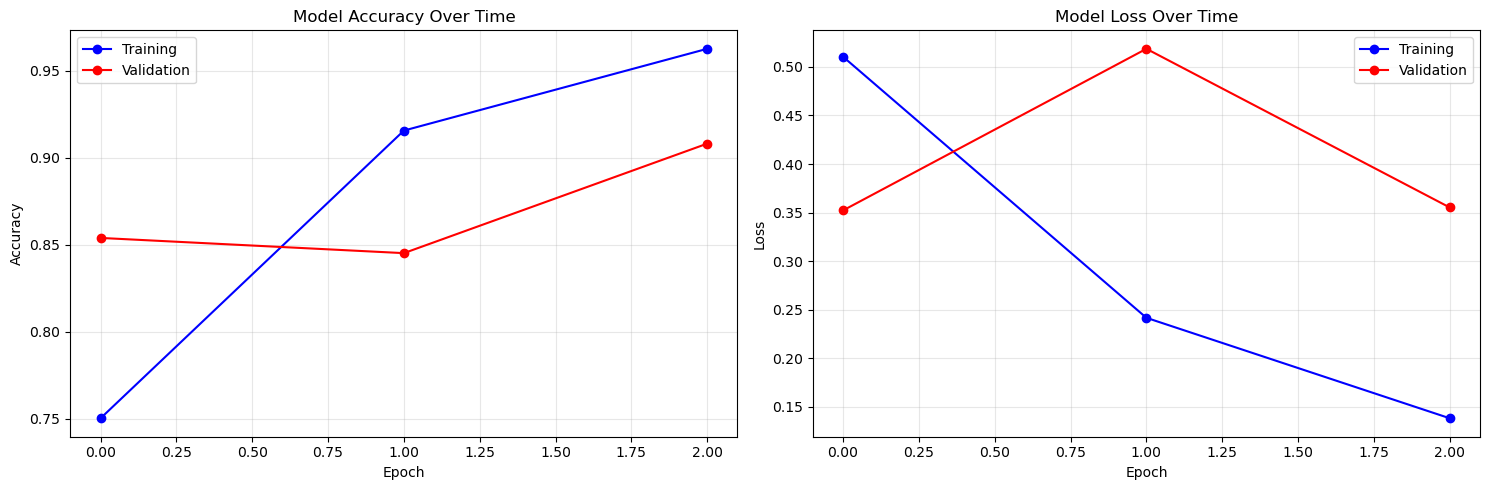

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history['train_accuracy'], 'b-o', label='Training')
ax1.plot(history['val_accuracy'], 'r-o', label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history['train_loss'], 'b-o', label='Training')
ax2.plot(history['val_loss'], 'r-o', label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 CELL 15: Test the Best Model

In [91]:
# Load the best model
model.load_state_dict(torch.load('best_bert_model.pt'))
print("Best model loaded!")

# Evaluate on test set
test_acc, test_loss, predictions, true_labels = evaluate_model(model, test_loader, device)

print(f'\nTest Results:')
print(f'Accuracy: {test_acc:.4f}')
print(f'Loss: {test_loss:.4f}')


Best model loaded!


Evaluating: 100%|██████████| 72/72 [01:29<00:00,  1.24s/it]


Test Results:
Accuracy: 0.9170
Loss: 0.3060


CELL 16: Detailed Metrics

In [92]:
# Calculate precision, recall, and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predictions, average='weighted'
)

print(f'\nDetailed Test Metrics:')
print(f'Accuracy:  {test_acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

# Classification report
sentiment_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
print('\nClassification Report:')
print(classification_report(true_labels, predictions, 
                          target_names=[sentiment_names[i] for i in range(num_classes)]))



Detailed Test Metrics:
Accuracy:  0.9170
Precision: 0.9177
Recall:    0.9170
F1-Score:  0.9168

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.88      0.91       522
     neutral       0.90      0.95      0.93       623

    accuracy                           0.92      1145
   macro avg       0.92      0.91      0.92      1145
weighted avg       0.92      0.92      0.92      1145



 CELL 17: Confusion Matrix

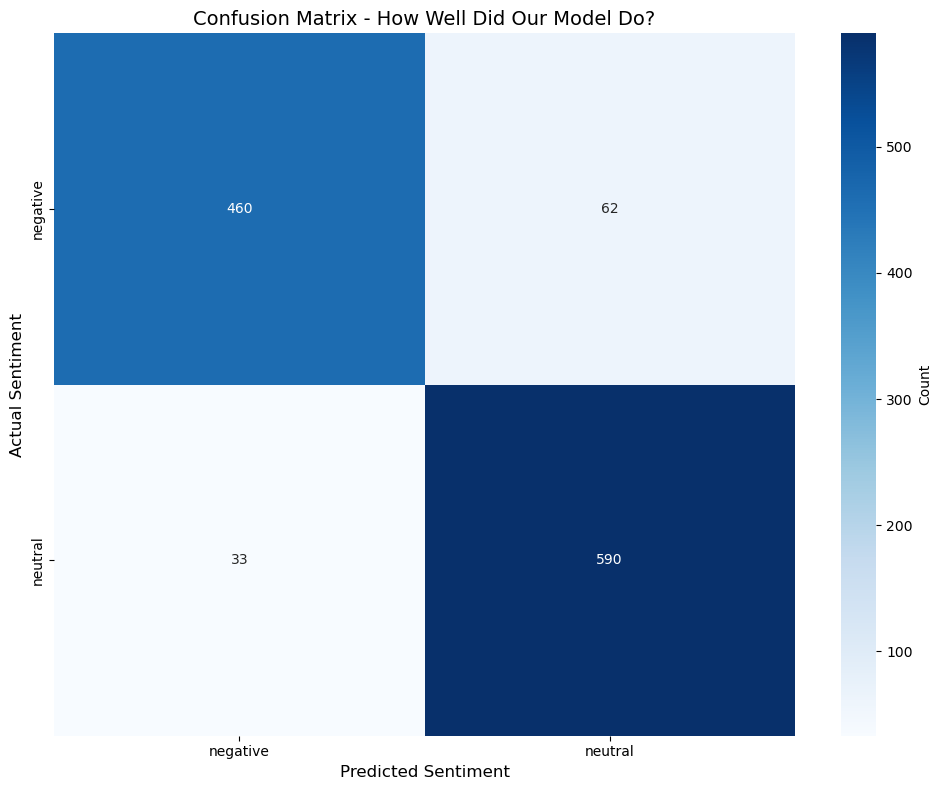

In [93]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[sentiment_names[i] for i in range(num_classes)],
            yticklabels=[sentiment_names[i] for i in range(num_classes)],
            cbar_kws={'label': 'Count'})
plt.ylabel('Actual Sentiment', fontsize=12)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.title('Confusion Matrix - How Well Did Our Model Do?', fontsize=14)
plt.tight_layout()
plt.show()

 CELL 18: Function to Predict New Text

In [95]:
def predict_sentiment(text, model, tokenizer, device):
    """
    Predict sentiment for any text
    """
    model.eval()
    
    # Prepare the text
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Make prediction
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=1)
    
    return sentiment_names[prediction.item()]


 CELL 19: Try Some Examples

In [96]:
# Let's test with some example texts
examples = [
    "I absolutely love this! Best thing ever!",
    "This is terrible. Worst experience of my life.",
    "It's okay, nothing special really.",
    "Amazing quality! Highly recommended!",
    "Disappointed with the service. Not happy.",
]

print("Testing with custom examples:\n")
print("=" * 70)

for text in examples:
    sentiment = predict_sentiment(text, model, tokenizer, device)
    print(f"\nText: {text}")
    print(f"Predicted Sentiment: {sentiment.upper()}")
    print("-" * 70)

print("\n✓ All done! Your BERT sentiment analyzer is ready to use!")

Testing with custom examples:


Text: I absolutely love this! Best thing ever!
Predicted Sentiment: NEUTRAL
----------------------------------------------------------------------

Text: This is terrible. Worst experience of my life.
Predicted Sentiment: NEGATIVE
----------------------------------------------------------------------

Text: It's okay, nothing special really.
Predicted Sentiment: NEUTRAL
----------------------------------------------------------------------

Text: Amazing quality! Highly recommended!
Predicted Sentiment: NEUTRAL
----------------------------------------------------------------------

Text: Disappointed with the service. Not happy.
Predicted Sentiment: NEUTRAL
----------------------------------------------------------------------

✓ All done! Your BERT sentiment analyzer is ready to use!
